# 01 — Data exploration: real failure physics, then our building

This notebook does one job: **justify the failure thresholds** used everywhere
else in the project. It does not train anything.

The obvious weakness of a simulated digital twin is that its failure thresholds
are whatever the author chose. We remove that by inheriting them from the **UCI
AI4I 2020 Predictive Maintenance Dataset** — real, published, with *documented*
failure rules — and verifying those rules reproduce exactly before reusing them.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 4)

## 1. The reference dataset (UCI AI4I 2020)

In [2]:
ai4i = pd.read_csv("data/ai4i2020.csv")
print(f"rows: {len(ai4i):,}")
print(f"machine failures: {int(ai4i['Machine failure'].sum())} "
      f"({100*ai4i['Machine failure'].mean():.2f}%)")
ai4i[["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]",
      "Torque [Nm]","Tool wear [min]"]].describe().round(2)

rows: 10,000
machine failures: 339 (3.39%)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


failures by mode: {'TWF': 46, 'HDF': 115, 'PWF': 95, 'OSF': 98, 'RNF': 19}


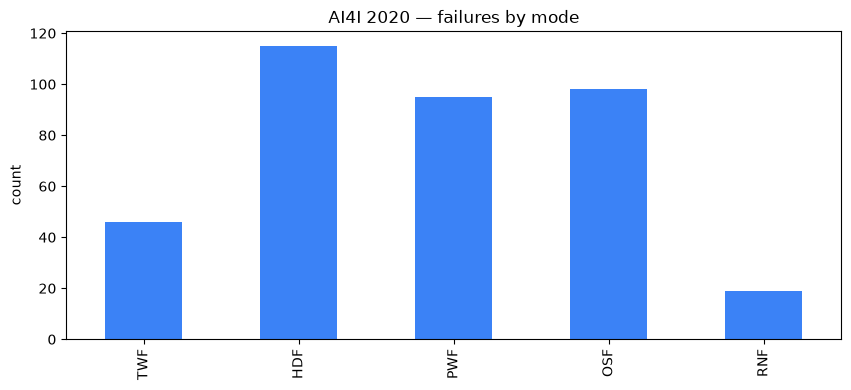

In [3]:
modes = {c: int(ai4i[c].sum()) for c in ["TWF","HDF","PWF","OSF","RNF"]}
print("failures by mode:", modes)
ax = pd.Series(modes).plot.bar(color="#3b82f6")
ax.set_title("AI4I 2020 — failures by mode"); ax.set_ylabel("count"); plt.show()

### Verifying the documented rule

AI4I documents heat-dissipation failure as: *(process temperature − air
temperature) < 8.6 K **and** rotational speed < 1380 rpm*.

If that rule is real, filtering on it should select exactly the HDF rows. This
is the check that turns "we picked some thresholds" into "we inherited
published ones".

In [4]:
selected = ai4i[(ai4i["Process temperature [K]"] - ai4i["Air temperature [K]"] < 8.6)
                & (ai4i["Rotational speed [rpm]"] < 1380)]
print(f"rows matching the documented HDF rule : {len(selected)}")
print(f"of those, flagged HDF in the dataset  : {int(selected['HDF'].sum())}")
print(f"total HDF rows in the dataset         : {int(ai4i['HDF'].sum())}")
assert len(selected) == int(selected["HDF"].sum()) == int(ai4i["HDF"].sum())
print("\nEXACT 1:1 match - the published rule is load-bearing, not approximate.")

rows matching the documented HDF rule : 115
of those, flagged HDF in the dataset  : 115
total HDF rows in the dataset         : 115

EXACT 1:1 match - the published rule is load-bearing, not approximate.


### How the rules map onto an HVAC fan motor

| AI4I mode | AI4I rule | Our analogue | Constant |
|---|---|---|---|
| **HDF** | (process − air) < 8.6 K and rpm < 1380 | Motor cannot shed heat into room air | `HDF_DELTA_K=8.6`, `HDF_RPM_MIN=1380` |
| **PWF** | torque × ω outside [3500, 9000] W | Draw outside the band expected for the commanded duty | `[0.56, 1.43] ×` expected |
| **OSF** | tool_wear × torque > 11000 min·Nm | runtime × torque past rated duty | `183.3 h·Nm` |
| **TWF** | wear ∈ [200, 240] min | Filter exhausted → airflow failure | `clog > 0.85` |

Rescaling arithmetic is in `data/README.md`. Thresholds that do **not** come
from AI4I (the 85 °C Class-F insulation limit, ISO 10816 vibration bands) are
listed there separately, so the citation is not overclaimed.

## 2. Our building's telemetry

In [5]:
df = pd.read_csv("data/building_telemetry.csv", parse_dates=["timestamp_iso"])
print(f"rows: {len(df):,}   span: {df.timestamp_iso.min().date()} -> {df.timestamp_iso.max().date()}")
print(f"failure events (segments ending in failure): {df.segment_id.nunique()} segments")
print(f"positive rate  4h: {100*df.label_failure_within_4h.mean():.3f}%"
      f"   30min: {100*df.label_failure_within_30min.mean():.3f}%")

rows: 630,720   span: 2026-01-01 -> 2027-01-01
failure events (segments ending in failure): 612 segments
positive rate  4h: 1.737%   30min: 0.218%


**Why the event count matters more than the row count.** Rows five minutes
apart inside one degradation segment are near-duplicates. A dataset of 630k
rows containing 228 events is a *228-sample* problem. This is why the trace is
a full year rather than the 90 days first generated, which held only 53 events.

In [6]:
per_room = df.groupby("twin_id").agg(
    rows=("twin_id","size"),
    positives_4h=("label_failure_within_4h","sum"),
    segments=("segment_id","nunique"),
    mean_temp=("room_temp","mean"),
    max_motor_temp=("motor_temp","max"),
).assign(positive_rate_pct=lambda d: (100*d.positives_4h/d.rows).round(3))
per_room.round(2)

,rows,positives_4h,segments,mean_temp,max_motor_temp,positive_rate_pct
twin_id,,,,,,
f1/lab-a,105120,145,99,25.45,85.00,0.14
f1/lab-b,105120,1056,84,25.46,69.89,1.00
f1/server-room,105120,4418,237,24.61,80.82,4.20
f2/lab-c,105120,2353,96,25.37,84.81,2.24
f2/meeting-room,105120,1201,26,25.34,43.41,1.14
f2/office,105120,1780,70,25.43,83.16,1.69


failure MODE mix per room:


label_failure_type,hdf,osf,pwf
twin_id,,,
f1/lab-a,145,0,0
f1/lab-b,0,720,336
f1/server-room,0,4418,0
f2/lab-c,48,2305,0
f2/meeting-room,0,1201,0
f2/office,0,1444,336


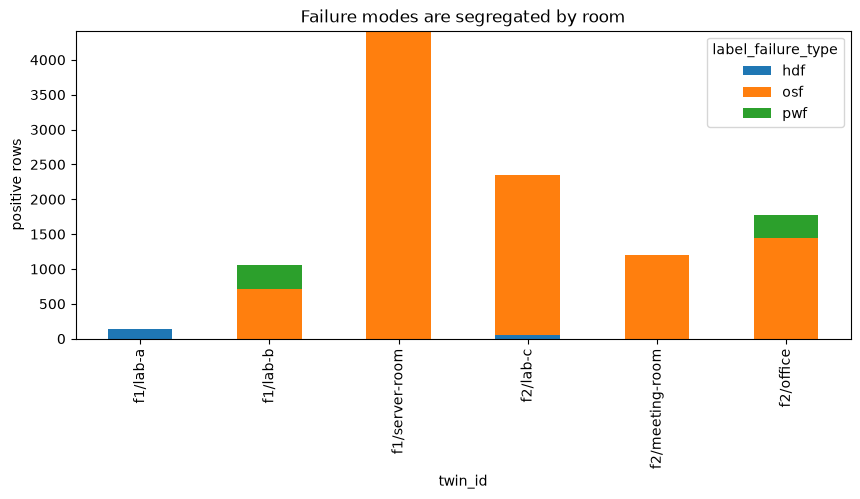

In [7]:
pos = df[df.label_failure_within_4h == 1]
mix = pd.crosstab(pos.twin_id, pos.label_failure_type)
print("failure MODE mix per room:"); display(mix)
mix.plot.bar(stacked=True); plt.title("Failure modes are segregated by room")
plt.ylabel("positive rows"); plt.show()

**This chart is the single most important finding in the project.**

Failure modes are almost perfectly segregated by room. `f1/lab-a` fails only by
heat dissipation; the server room only by overstrain. Overstrain accounts for
roughly 10k of ~11k positive rows.

Two consequences follow, and both are dealt with in notebook 02:

1. A binary classifier optimises for the majority mode and goes **blind** to the
   others. We predict the fault *type* instead.
2. Per-room performance disparity is really per-*mode* disparity. A fairness
   audit that stops at "lab-a scores badly" would miss the cause.

## 3. Degradation over time

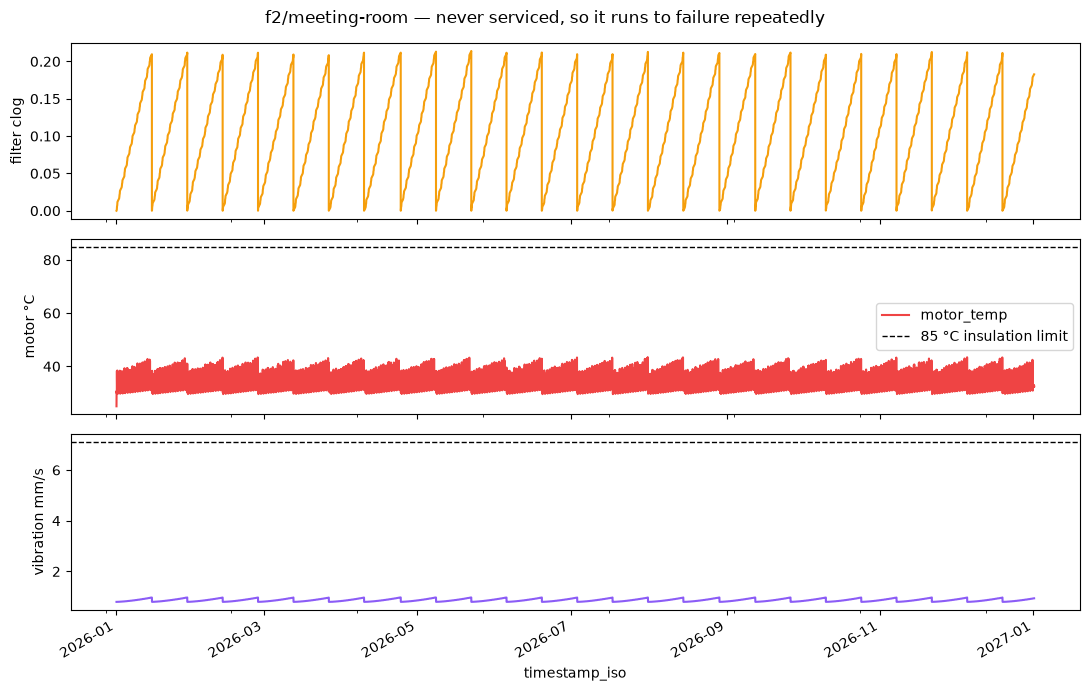

In [8]:
room = df[df.twin_id == "f2/meeting-room"].set_index("timestamp_iso")
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
room["filter_clog"].plot(ax=axes[0], color="#f59e0b"); axes[0].set_ylabel("filter clog")
room["motor_temp"].plot(ax=axes[1], color="#ef4444"); axes[1].set_ylabel("motor °C")
axes[1].axhline(85, ls="--", c="k", lw=1, label="85 °C insulation limit"); axes[1].legend()
room["vibration_mm_s"].plot(ax=axes[2], color="#8b5cf6"); axes[2].set_ylabel("vibration mm/s")
axes[2].axhline(7.1, ls="--", c="k", lw=1)
fig.suptitle("f2/meeting-room — never serviced, so it runs to failure repeatedly")
plt.tight_layout(); plt.show()

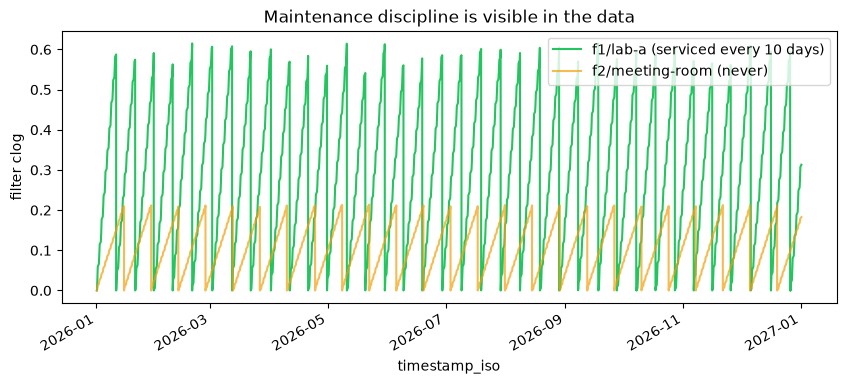

In [9]:
served = df[df.twin_id == "f1/lab-a"].set_index("timestamp_iso")
ax = served["filter_clog"].plot(color="#22c55e", label="f1/lab-a (serviced every 10 days)")
room["filter_clog"].plot(ax=ax, color="#f59e0b", alpha=.7, label="f2/meeting-room (never)")
ax.set_ylabel("filter clog"); ax.legend(); ax.set_title("Maintenance discipline is visible in the data")
plt.show()

The sawtooth is planned servicing. The contrast between these two rooms is the
**deliberate distribution shift** the fairness audit needs — without it, a
finding of "no disparity" would be vacuous.

## 4. Class imbalance

In [10]:
counts = df.label_failure_within_4h.value_counts()
print(counts.to_string())
print(f"\nA model predicting 'no failure' always would score "
      f"{100*counts[0]/len(df):.2f}% accuracy and be worthless.")
print("This is why PR-AUC, not accuracy, is the headline metric in notebook 02.")

label_failure_within_4h
0    619767
1     10953

A model predicting 'no failure' always would score 98.26% accuracy and be worthless.
This is why PR-AUC, not accuracy, is the headline metric in notebook 02.
